# ETL → Star Schema: A Data-Engineering Pipeline

**Author:** Aman Bohra · Senior Analytics & BI Professional
**Portfolio:** https://amandbohra.github.io/portfolio/

Dashboards are only as good as the model beneath them. This notebook walks a small **ETL/ELT pipeline**:
raw operational rows → cleaned staging → a **dimensional star schema** (fact + dimensions) in SQLite →
an analytical query that a BI tool would sit on. It's the data-engineering foundation behind good BI.

> ⚠️ Synthetic data for demonstration only — no real or confidential client data.


In [1]:
import numpy as np, pandas as pd, sqlite3, matplotlib.pyplot as plt
plt.rcParams.update({"figure.facecolor":"white","axes.grid":True,"grid.alpha":0.25})
rng = np.random.default_rng(5)


## 1. Extract — raw operational data
A messy "sales transactions" extract, the kind you'd pull from a source system.

In [2]:
n = 3000
regions = ["North","South","East","West"]
products = ["Property","Auto","Liability","Marine","Specialty"]
raw = pd.DataFrame({
    "txn_id": np.arange(1, n+1),
    "date": pd.to_datetime("2024-01-01") + pd.to_timedelta(rng.integers(0, 365, n), unit="D"),
    "region": rng.choice(regions, n),
    "product": rng.choice(products, n, p=[.34,.27,.18,.11,.10]),
    "distributor": rng.integers(1, 21, n),
    "premium": (rng.normal(1400, 400, n)).round(2),
})
raw.loc[rng.choice(n, 30, replace=False), "premium"] = np.nan   # a few nulls to clean
raw.head()


,txn_id,date,region,product,distributor,premium
0,1,2024-09-01,North,Auto,2,1762.24
1,2,2024-10-20,South,Specialty,12,1394.63
2,3,2024-01-09,North,Auto,13,1372.05
3,4,2024-10-21,South,Marine,14,2471.96
4,5,2024-06-20,North,Property,3,1379.64


## 2. Transform — clean & conform (staging)

In [3]:
stg = raw.copy()
stg = stg.dropna(subset=["premium"])
stg = stg[stg["premium"] > 0]
stg["date"] = pd.to_datetime(stg["date"])
stg["year"] = stg["date"].dt.year
stg["month"] = stg["date"].dt.month
print(f"raw rows: {len(raw)} -> clean rows: {len(stg)}")
stg.head()


raw rows: 3000 -> clean rows: 2969


,txn_id,date,region,product,distributor,premium,year,month
0,1,2024-09-01,North,Auto,2,1762.24,2024,9
1,2,2024-10-20,South,Specialty,12,1394.63,2024,10
2,3,2024-01-09,North,Auto,13,1372.05,2024,1
3,4,2024-10-21,South,Marine,14,2471.96,2024,10
4,5,2024-06-20,North,Property,3,1379.64,2024,6


## 3. Load — build the star schema (dimensions + fact)

In [4]:
# Dimensions
dim_region = pd.DataFrame({"region": sorted(stg.region.unique())})
dim_region["region_id"] = np.arange(1, len(dim_region)+1)
dim_product = pd.DataFrame({"product": sorted(stg["product"].unique())})
dim_product["product_id"] = np.arange(1, len(dim_product)+1)
dim_date = stg[["date","year","month"]].drop_duplicates().sort_values("date").reset_index(drop=True)
dim_date["date_id"] = np.arange(1, len(dim_date)+1)

# Fact — surrogate keys via joins
fact = (stg.merge(dim_region, on="region")
           .merge(dim_product, on="product")
           .merge(dim_date[["date","date_id"]], on="date")
        [["txn_id","date_id","region_id","product_id","distributor","premium"]]
        .rename(columns={"distributor":"distributor_id","premium":"premium_amt"}))

# Persist to SQLite (the "warehouse")
con = sqlite3.connect(":memory:")
for name, d in {"dim_region":dim_region,"dim_product":dim_product,"dim_date":dim_date,"fact_premium":fact}.items():
    d.to_sql(name, con, index=False, if_exists="replace")
print("fact_premium rows:", len(fact))
fact.head()


fact_premium rows: 2969


,txn_id,date_id,region_id,product_id,distributor_id,premium_amt
0,1,245,2,1,2,1762.24
1,2,294,3,5,12,1394.63
2,3,9,2,1,13,1372.05
3,4,295,3,3,14,2471.96
4,5,172,2,4,3,1379.64


## 4. Analytical query — what BI sits on
A star schema makes analytical SQL simple and fast: join fact to dimensions, aggregate.

In [5]:
q = '''
SELECT p.product, d.month, ROUND(SUM(f.premium_amt)/1e6, 3) AS premium_musd
FROM fact_premium f
JOIN dim_product p ON p.product_id = f.product_id
JOIN dim_date   d ON d.date_id    = f.date_id
GROUP BY p.product, d.month
ORDER BY d.month, premium_musd DESC;
'''
res = pd.read_sql(q, con)
pivot = res.pivot(index="month", columns="product", values="premium_musd").fillna(0)
pivot.head()


product,Auto,Liability,Marine,Property,Specialty
month,,,,,
1,0.110,0.067,0.041,0.143,0.030
2,0.074,0.060,0.041,0.103,0.036
3,0.102,0.063,0.041,0.116,0.031
4,0.075,0.052,0.033,0.109,0.022
5,0.099,0.054,0.036,0.151,0.039


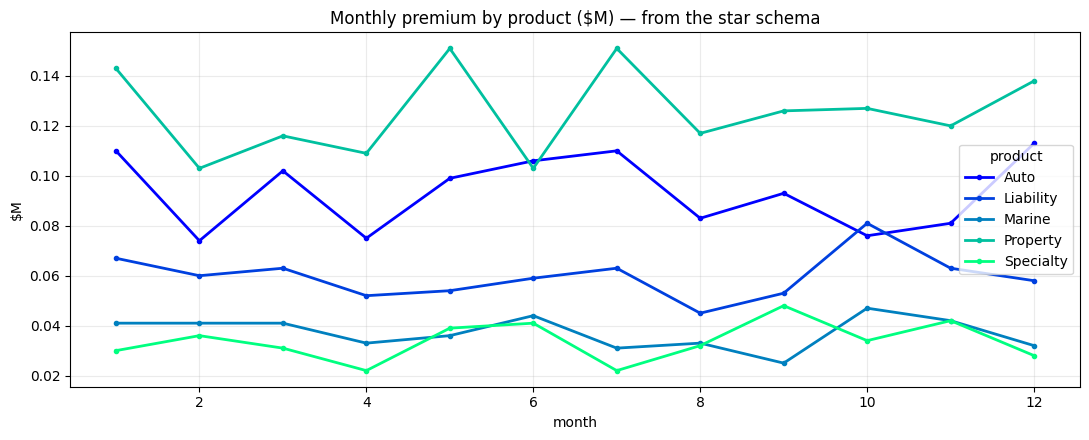

In [6]:
ax = pivot.plot(figsize=(11,4.5), lw=2, marker="o", ms=3, colormap="winter")
ax.set_title("Monthly premium by product ($M) — from the star schema")
ax.set_ylabel("$M"); ax.set_xlabel("month"); plt.tight_layout(); plt.show()
con.close()


## 5. Why this matters
- **ETL vs ELT** — same idea, different order: transform-then-load, or load-raw-then-transform in the
  warehouse (Databricks/SQL). Either way, the destination is a clean, conformed model.
- **Star schema** — fact + dimensions keep queries simple, fast, and consistent across every dashboard.
- **Governance** — cleaning and conforming *once* in the pipeline is why every downstream report agrees.

This is the unglamorous layer that makes BI trustworthy. Get it right and the dashboards take care of themselves.

*— Aman Bohra*
